# GR2L green-roof model vs measured soil-water content

This notebook drives the **GR2L** two-layer water-balance model with **measured** weather
from the facility's own DuckDB warehouse and compares the model's predicted substrate
water storage against the **measured** soil-water content (SWC) sensors.

Pipeline:
1. Query daily **meteo** (`wetter`) and **SWC** (`swc`) from `data/water.duckdb`.
2. Feed the measured daily weather into GR2L (one API call per roof type).
3. Convert both series to volumetric water content θ (%) and plot **measured vs predicted**.

The GR2L API (where the model lives + its key) is configured **in the next cell** — fill
in your deployment there.

## 1. Configuration — GR2L API, site, and analysis window

`GR2L_API_BASE_URL` is the base URL **including the deployment prefix**; the notebook POSTs
to `{GR2L_API_BASE_URL}/predict_gr2l`.

In [1]:
# --- GR2L model API (fill in your deployment) ---
GR2L_API_BASE_URL = "http://localhost:8000/api-weinbau"   # POSTs to {this}/predict_gr2l
GR2L_API_KEY = "new-extra-security-api-key-for-wombat"                     # sent as the API-KEY header

# --- Green-roof facility (Leipzig) --- used for GR2L geometry (elevation/lat/long) ---
SITE_LAT, SITE_LON, SITE_ELEV = 51.34, 12.38, 113.0

# --- Analysis window (must fall inside the swc ∩ wetter overlap: 2025-01-01 .. 2026-04-24) ---
START = "2025-03-01"
END = "2025-11-01"          # exclusive upper bound

# --- Data warehouse (relative to notebooks/, matching the other notebooks) ---
DUCKDB_PATH = "../data/water.duckdb"

# --- Meteo unit assumptions (verify against the station manual) ---
# wetter.windspeed is assumed m/s   -> GR2L wants km/h        -> x 3.6
# wetter.Rad_SW    is assumed W/m2  -> GR2L wants J/cm2/day    -> mean(W/m2) x 86400 / 1e4 = x 8.64
WIND_MS_TO_KMH = 3.6
RAD_WM2_TO_JCM2DAY = 8.64

In [2]:
import duckdb
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the project's roof-parameter presets and request/response schemas so the
# notebook stays in lock-step with the GR2L tool.
from water_assistant_agent.assistant.tools.gr2l_client import ROOF_PRESETS
from water_assistant_agent.assistant.tools.schemas import (
    DailyWeatherRow,
    Gr2lRequest,
    Gr2lResultRow,
)

ROOF_PRESETS

{'wetland': {'SH': 1.7,
  'Ssubmin': 1.3,
  'Ssubmax': 90,
  'Sret': 0,
  'Sretmax': 0,
  'theta_02': 0,
  'kg': 1,
  'albedo': 0.06,
  'open_water': True},
 'non_irrigated_extensive': {'SH': 7,
  'Ssubmin': 0.9,
  'Ssubmax': 16.0,
  'Sret': 0,
  'Sretmax': 0,
  'theta_02': 0,
  'kg': 1,
  'albedo': 0.2,
  'open_water': False},
 'irrigated_extensive': {'SH': 7,
  'Ssubmin': 3.3,
  'Ssubmax': 22.8,
  'Sret': 0,
  'Sretmax': 0,
  'theta_02': 0,
  'kg': 1,
  'albedo': 0.2,
  'open_water': False},
 'semi_intensive': {'SH': 15,
  'Ssubmin': 6.3,
  'Ssubmax': 45.6,
  'Sret': 0,
  'Sretmax': 0,
  'theta_02': 0,
  'kg': 1,
  'albedo': 0.2,
  'open_water': False}}

## 2. Query daily weather + SWC from DuckDB

Both tables are half-hourly; we aggregate to the **daily** step GR2L runs on. `wetter` has
no minimum-temperature column, so `tn` uses the daily minimum of the half-hourly mean
temperature as a proxy. Radiation and wind are converted with the factors above.

In [3]:
WEATHER_SQL = f"""
    SELECT CAST(timestamp AS DATE)      AS \"Date\",
           AVG(Tmean)                   AS tm,      -- mean temperature, C
           MAX(Tmax)                    AS tx,      -- max temperature, C
           MIN(Tmean)                   AS tn,      -- min temperature proxy (no Tmin column), C
           AVG(RH)                      AS rf,      -- relative humidity, %
           SUM(Rain)                    AS precip,  -- precipitation, mm
           -- windspeed carries a -7999 missing-data sentinel; exclude it from the mean
           AVG(windspeed) FILTER (WHERE windspeed >= 0) * {WIND_MS_TO_KMH} AS w,   -- wind, km/h
           AVG(Rad_SW)   * {RAD_WM2_TO_JCM2DAY} AS gs,  -- global radiation, J/cm2/day
           COUNT(*)                     AS n
    FROM wetter
    WHERE timestamp >= ? AND timestamp < ?
    GROUP BY 1
    HAVING COUNT(*) >= 44      -- drop partial days
    ORDER BY 1
"""

SWC_SQL = """
    SELECT CAST(timestamp AS DATE) AS \"Date\",
           AVG(QEx1)     AS QEx1,       -- irrigated extensive
           AVG(QEx2)     AS QEx2,       -- non-irrigated extensive
           AVG(QIn)      AS QIn,        -- semi-intensive
           AVG(QWetland) AS QWetland    -- wetland
    FROM swc
    WHERE timestamp >= ? AND timestamp < ?
    GROUP BY 1
    ORDER BY 1
"""

with duckdb.connect(DUCKDB_PATH, read_only=True) as con:
    weather = con.execute(WEATHER_SQL, [START, END]).fetchdf()
    swc = con.execute(SWC_SQL, [START, END]).fetchdf()

# Keep only days present in both tables and with no missing field (e.g. an all-sentinel
# wind day -> NaN), and format Date as GR2L's YYYY-MM-DD string.
daily = weather.merge(swc, on="Date").dropna().reset_index(drop=True)
daily["Date"] = pd.to_datetime(daily["Date"]).dt.strftime("%Y-%m-%d")
print(f"{len(daily)} daily rows: {daily['Date'].iloc[0]} -> {daily['Date'].iloc[-1]}")
print(f"w (km/h) range: {daily['w'].min():.1f} .. {daily['w'].max():.1f}   "
      f"gs (J/cm2/day) range: {daily['gs'].min():.0f} .. {daily['gs'].max():.0f}")
daily.head()

233 daily rows: 2025-03-01 -> 2025-10-23
w (km/h) range: 2.4 .. 16.2   gs (J/cm2/day) range: 144 .. 2344


,Date,tm,tx,tn,rf,precip,w,gs,n,QEx1,QEx2,QIn,QWetland
0,2025-03-01,3.673508,6.30,2.046133,92.489653,0.731,4.607448,333.655146,48,26.015552,19.150340,25.515071,85.894812
1,2025-03-02,3.672526,8.42,0.657733,87.113035,0.000,5.548642,806.315382,48,24.799204,18.450925,25.112193,85.910275
2,2025-03-03,4.498459,11.70,-0.936133,71.962174,0.000,4.699710,1032.027966,48,22.354230,17.202683,24.736045,85.924344
3,2025-03-04,5.970633,13.95,-0.702300,63.358833,0.000,4.643570,964.276476,48,20.540575,16.112296,24.382609,85.927438
4,2025-03-05,8.474638,17.48,1.427833,54.652729,0.000,5.308030,1097.774022,48,19.380990,15.162882,24.035483,86.007228


## 3. Roof mapping and θ ↔ storage conversion

Each SWC column is one roof type. GR2L reports substrate storage `Ssub` in **mm**; the
sensors report volumetric water content θ in **%**. They convert with GR2L's depth relation
`S_mm = (θ% / 100) × SH_mm`, where `SH_mm = SH_cm × 10`.

> **Wetland (`QWetland`):** the store is a **17 mm water-storage mat** (recycled
> polypropylene fleece, `SH = 1.7 cm`) that ponds water above it up to the **9 cm outlet
> standpipes** — hence the structural `Ssubmax = 90 mm` (Moeller et al. 2025). The mat's
> SWC sensor saturates at ~86 % θ (≈ 14.7 mm over the mat depth): pond water above the
> mat is invisible to it. For the θ comparison, predicted storage is therefore **capped
> at the mat saturation** before converting — `Ssub ≥ 14.7 mm` simply reads as ~86 %.
> `open_water=True` makes GR2L evaporate at the potential rate (`ET = ET_PM`, no
> `Ssub/Ssubmax` throttling) while still tracking the water balance.
>
> **Known limitation:** all segments are **drip-irrigated** (the wetland included), and
> irrigation is not in `wetter.Rain` — the 2025 record shows ~24 rain-free days with θ
> rising 2–13 %/day. Driven by rain alone, GR2L is a **lower bound** on wetland storage;
> Section 6 marks the irrigation events explicitly.

In [4]:
# swc column -> GR2L roof-type preset key
ROOF_MAP = {
    "QEx1": "irrigated_extensive",
    "QEx2": "non_irrigated_extensive",
    "QIn": "semi_intensive",
    "QWetland": "wetland",
}

# Storage level (mm) at which the roof's SWC sensor saturates. Only the wetland
# needs one: its mat reads ~86% theta when full (14.7 mm over 17 mm depth), and
# pond water above the mat (up to Ssubmax=90) is invisible to the sensor.
SENSOR_CAP_MM = {"wetland": 14.7}


def sh_mm(roof_type: str) -> float:
    """Substrate depth in mm for a roof-type preset."""
    return ROOF_PRESETS[roof_type]["SH"] * 10.0


def theta_to_storage(theta_pct, roof_type):
    """Volumetric water content θ (%) -> substrate storage (mm)."""
    return theta_pct / 100.0 * sh_mm(roof_type)


def storage_to_theta(s_mm, roof_type):
    """Substrate storage (mm) -> the θ (%) the roof's SWC sensor would read."""
    capped = np.minimum(s_mm, SENSOR_CAP_MM.get(roof_type, np.inf))
    return capped / sh_mm(roof_type) * 100.0

## 4. Call GR2L

The request is built from the roof preset plus the site geometry and an initial-moisture
seed; it is POSTed straight to the configured endpoint. Every day's measured weather row
goes in, one GR2L output row comes back.

In [5]:
def call_gr2l(rows: list[DailyWeatherRow], roof_type: str, theta_01: float) -> pd.DataFrame:
    """POST daily weather + roof parameters to GR2L; return the per-day result as a DataFrame."""
    params = dict(ROOF_PRESETS[roof_type])
    params.update(hoehe_nn=SITE_ELEV, lat=SITE_LAT, long=SITE_LON, theta_01=theta_01)
    request = Gr2lRequest(data=rows, **params)

    url = f"{GR2L_API_BASE_URL.rstrip('/')}/predict_gr2l"
    headers = {"API-KEY": GR2L_API_KEY, "Content-Type": "application/json"}
    with httpx.Client(timeout=90) as client:
        resp = client.post(url, json=request.model_dump(exclude_none=True), headers=headers)
        resp.raise_for_status()

    result_rows = [Gr2lResultRow.model_validate(r) for r in resp.json()["data"]]
    return pd.DataFrame([r.model_dump() for r in result_rows])

In [6]:
# Build the shared measured-weather rows once (same weather drives every roof).
weather_rows = [
    DailyWeatherRow(
        Date=str(r.Date), tm=float(r.tm), tx=float(r.tx), tn=float(r.tn),
        rf=float(r.rf), precip=float(r.precip), w=float(r.w), gs=float(r.gs),
    )
    for r in daily.itertuples()
]

# Run GR2L per roof, seeding day-1 moisture from the measured SWC so the series start
# aligned. Wetland exception: its sensor can't see pond water above the mat, and after
# the wet winter the pond is plausibly full -> seed at capacity (Ssubmax).
results = {}
for col, roof in ROOF_MAP.items():
    if ROOF_PRESETS[roof].get("open_water"):
        seed_storage = float(ROOF_PRESETS[roof]["Ssubmax"])
    else:
        seed_storage = theta_to_storage(daily[col].iloc[0], roof)
    pred = call_gr2l(weather_rows, roof, theta_01=seed_storage)
    pred["Date"] = pd.to_datetime(pred["Date"])
    pred["theta_pred"] = storage_to_theta(pred["Ssub"], roof)
    pred["theta_meas"] = daily[col].to_numpy()
    results[roof] = pred
    print(f"{roof:<24} {len(pred)} days  seed θ_0={daily[col].iloc[0]:.1f}% (start {seed_storage:.1f} mm)")

results["semi_intensive"].head()

irrigated_extensive      233 days  seed θ_0=26.0% (start 18.2 mm)
non_irrigated_extensive  233 days  seed θ_0=19.2% (start 13.4 mm)
semi_intensive           233 days  seed θ_0=25.5% (start 38.3 mm)
wetland                  233 days  seed θ_0=85.9% (start 90.0 mm)


,Date,ET_PM,Ssub,Sret,Qdown,Qup,OUT,ET,theta_pred,theta_meas
0,2025-03-01,0.8224,38.2726,0.0,NaN,NaN,NaN,0.6902,25.515067,25.515071
1,2025-03-02,1.4227,37.0785,0.0,0.0,0.0,0.0,1.1941,24.719000,25.112193
2,2025-03-03,1.9931,35.4579,0.0,0.0,0.0,0.0,1.6206,23.638600,24.736045
3,2025-03-04,2.1726,33.7686,0.0,0.0,0.0,0.0,1.6893,22.512400,24.382609
4,2025-03-05,2.7722,31.7156,0.0,0.0,0.0,0.0,2.0529,21.143733,24.035483


## 5. Measured SWC vs GR2L prediction

For each roof, the measured θ and the GR2L-predicted θ over time, with error metrics
(RMSE, mean bias, correlation) in the panel title.

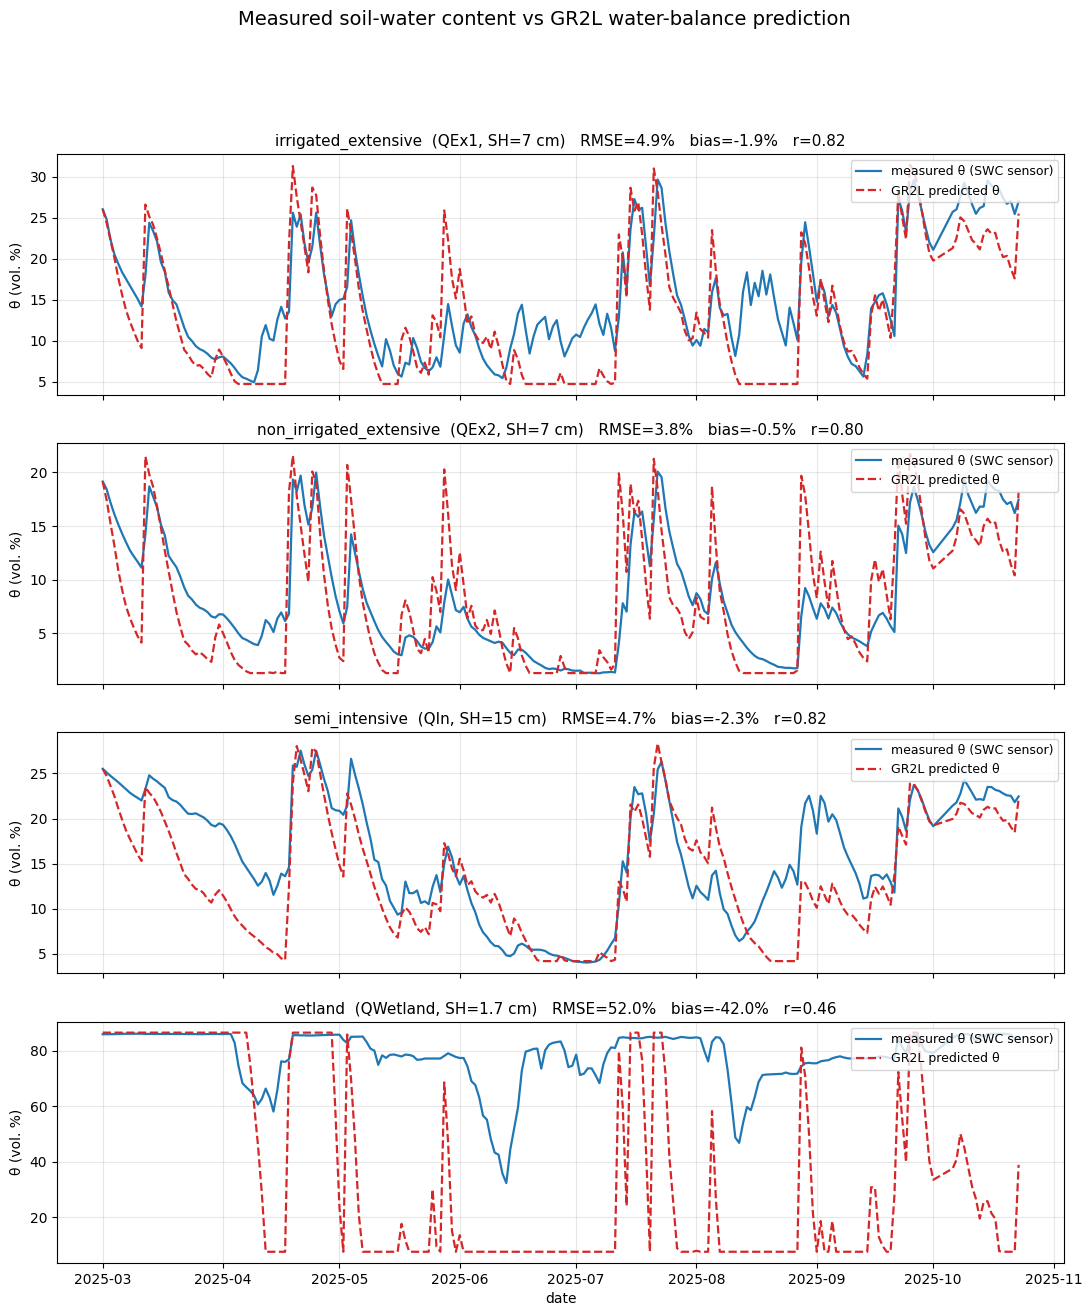

In [7]:
fig, axes = plt.subplots(len(ROOF_MAP), 1, figsize=(13, 3.6 * len(ROOF_MAP)), sharex=True)

for ax, (col, roof) in zip(axes, ROOF_MAP.items()):
    p = results[roof]
    ax.plot(p["Date"], p["theta_meas"], color="#1f77b4", lw=1.6, label="measured θ (SWC sensor)")
    ax.plot(p["Date"], p["theta_pred"], color="#d62728", lw=1.6, ls="--", label="GR2L predicted θ")

    resid = p["theta_pred"] - p["theta_meas"]
    rmse = float(np.sqrt((resid ** 2).mean()))
    bias = float(resid.mean())
    corr = float(p["theta_meas"].corr(p["theta_pred"]))
    sh = ROOF_PRESETS[roof]["SH"]
    ax.set_title(
        f"{roof}  ({col}, SH={sh:g} cm)   "
        f"RMSE={rmse:.1f}%   bias={bias:+.1f}%   r={corr:.2f}",
        fontsize=11,
    )
    ax.set_ylabel("θ (vol. %)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("date")
fig.suptitle("Measured soil-water content vs GR2L water-balance prediction", fontsize=14)
fig.tight_layout
plt.show()

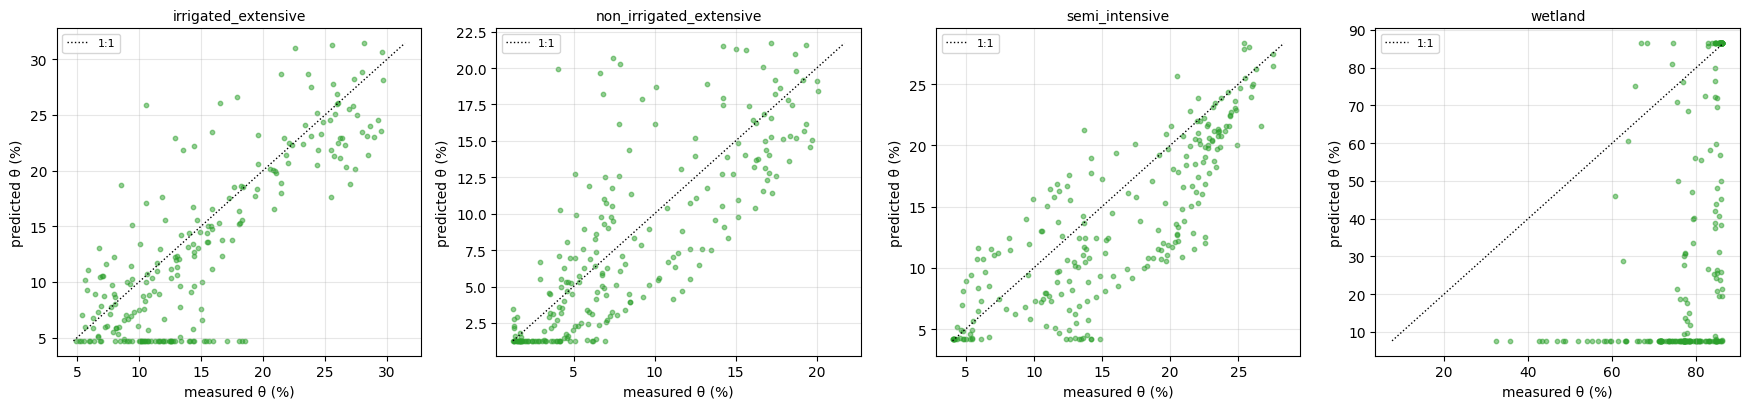

In [8]:
# Measured-vs-predicted scatter (1:1 line) as a compact goodness-of-fit view.
fig, axes = plt.subplots(1, len(ROOF_MAP), figsize=(4.4 * len(ROOF_MAP), 4.2))

for ax, (col, roof) in zip(axes, ROOF_MAP.items()):
    p = results[roof]
    ax.scatter(p["theta_meas"], p["theta_pred"], s=10, alpha=0.5, color="#2ca02c")
    lo = float(min(p["theta_meas"].min(), p["theta_pred"].min()))
    hi = float(max(p["theta_meas"].max(), p["theta_pred"].max()))
    ax.plot([lo, hi], [lo, hi], color="k", lw=1, ls=":", label="1:1")
    ax.set_title(roof, fontsize=10)
    ax.set_xlabel("measured θ (%)")
    ax.set_ylabel("predicted θ (%)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

## 6. Wetland deep-dive: rain-only simulation vs irrigation reality

The wetland run above is driven by **rain alone**, but the roof is also **drip-irrigated**
(all segments are; Moeller et al. 2025 — irrigation volumes are metered on site but are
not in this warehouse). Rain covers only ~40 % of the wetland's potential open-water
evaporation over the window (≈300 mm vs ≈760 mm), so the rain-only simulation *must*
dry out where the real roof was topped up.

The plot below makes that visible: days where measured θ **rises ≥ 1 %/day with < 0.5 mm
rain** are marked as inferred irrigation events — they cluster exactly where the model
and the sensor diverge (April, mid-June recovery, August). With a metered irrigation
series added to `precip`, GR2L could be validated properly against this roof.

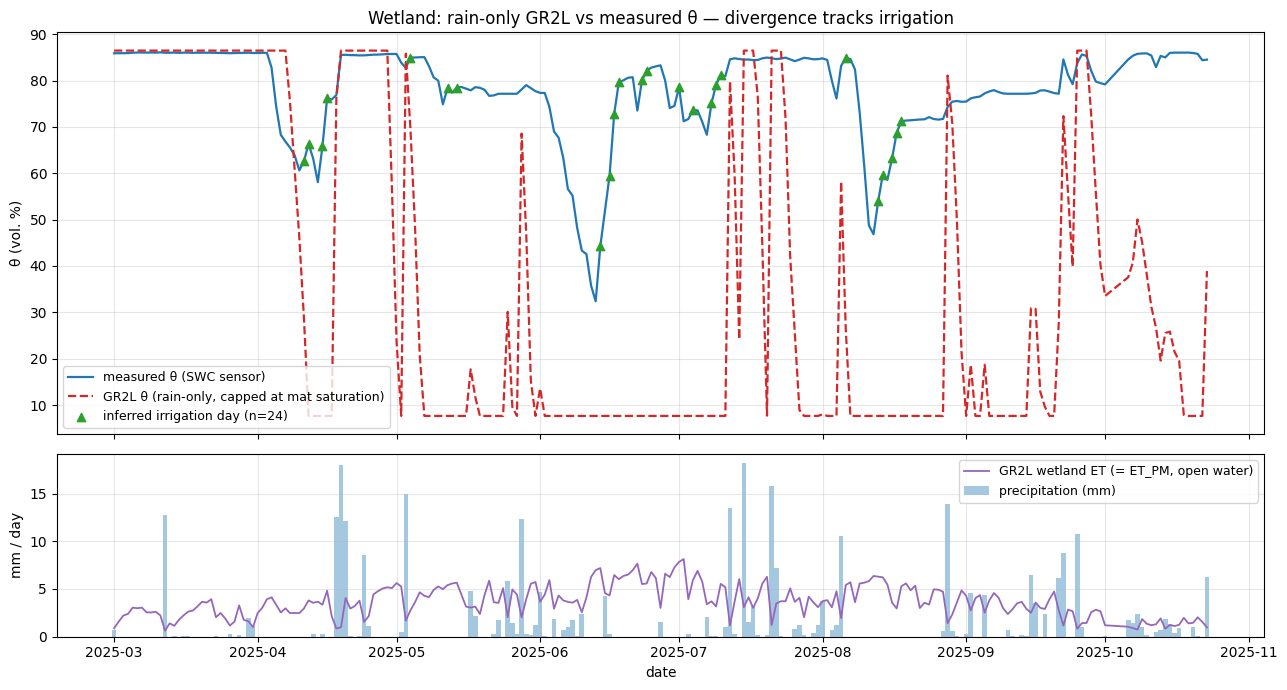

window totals: precip 303 mm  vs  wetland ET 847 mm (deficit 544 mm <- irrigation's job)
inferred irrigation days: 24


In [9]:
# Wetland: measured vs rain-only prediction, with inferred irrigation events marked.
w = results["wetland"]
dates = pd.to_datetime(daily["Date"])

# Inferred irrigation: measured theta rises >= 1%/day on a (nearly) rain-free day.
dtheta = daily["QWetland"].diff()
irr_days = (dtheta >= 1.0) & (daily["precip"] < 0.5)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

ax.plot(dates, w["theta_meas"], color="#1f77b4", lw=1.6, label="measured θ (SWC sensor)")
ax.plot(dates, w["theta_pred"], color="#d62728", lw=1.6, ls="--",
        label="GR2L θ (rain-only, capped at mat saturation)")
ax.scatter(dates[irr_days], w["theta_meas"][irr_days.to_numpy()], zorder=5, s=36,
           marker="^", color="#2ca02c", label=f"inferred irrigation day (n={int(irr_days.sum())})")
ax.set_title("Wetland: rain-only GR2L vs measured θ — divergence tracks irrigation", fontsize=12)
ax.set_ylabel("θ (vol. %)")
ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=9)

ax2.bar(dates, daily["precip"], width=1.0, alpha=0.4, color="#1f77b4", label="precipitation (mm)")
ax2.plot(dates, w["ET"], color="#9467bd", lw=1.3, label="GR2L wetland ET (= ET_PM, open water)")
ax2.set_ylabel("mm / day")
ax2.set_xlabel("date")
ax2.grid(alpha=0.3)
ax2.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

print(f"window totals: precip {daily['precip'].sum():.0f} mm  vs  wetland ET {w['ET'].sum():.0f} mm "
      f"(deficit {w['ET'].sum() - daily['precip'].sum():.0f} mm <- irrigation's job)")
print(f"inferred irrigation days: {int(irr_days.sum())}")

## Notes

- **Weather source is the measured `wetter` table**, not a forecast — this is a hindcast
  validation of GR2L against the site's own SWC sensors over the same period.
- **Unit assumptions** live in the config cell (`WIND_MS_TO_KMH`, `RAD_WM2_TO_JCM2DAY`). If
  the station records wind in km/h or radiation as a daily sum, adjust those factors.
- **Day-1 seeding:** substrate roofs are seeded (`theta_01`) from the measured SWC on the
  first day; the wetland is seeded at capacity (`Ssubmax = 90 mm`, pond full after winter),
  since its sensor cannot see pond water above the mat.
- **Wetland caveats:** `open_water=True` → `ET = ET_PM` (potential rate) with the water
  balance still tracked; predicted θ is capped at mat saturation (~86 %); and the run is
  **rain-only** while the real roof is drip-irrigated (Section 6) — so its θ panel in
  Section 5 is a lower bound, not a like-for-like validation. A metered irrigation series
  (Q3 water meter exists on site, per Moeller et al. 2025) added to `precip` would make it
  one. The `outflow.Sumpf2_Efflux` column also offers a runoff-side validation of `OUT`.
- **To change the window or roof set,** edit `START`/`END` in the config cell or `ROOF_MAP`.
- GR2L also returns `OUT` (runoff), `ET`/`ET_PM` (evapotranspiration), and `Sret` per day in
  `results[roof]` if you want to extend the comparison to stormwater retention or ET.